<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana8/Semana8Dia1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 10.0 MB/s eta 0:00:00


In [2]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("="*75)
print("DIA 1: O PODER DO YOLO PRÉ-TREINADO (ZERO-SHOT)")
print("="*75)

# ==============================================================================
# 1. IMPORTANDO O CÉREBRO DA IA
# ==============================================================================
print("-> Baixando os pesos do YOLOv8 Nano (O mais leve e rápido)...")
modelo_yolo = YOLO('yolov8n.pt') # Ele baixa automaticamente o modelo treinado em 80 classes

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
DIA 1: O PODER DO YOLO PRÉ-TREINADO (ZERO-SHOT)
-> Baixando os pesos do YOLOv8 Nano (O mais leve e rápido)...


In [3]:
# ==============================================================================
# 2. INFERÊNCIA NO MUNDO REAL
# ==============================================================================
# Vamos usar uma imagem urbana genérica via URL
url_imagem = "https://ultralytics.com/images/zidane.jpg"

print("\n-> Executando a Detecção de Objetos...")
# O parâmetro conf=0.50 aplica o corte de confiança (Threshold)
resultados = modelo_yolo.predict(source=url_imagem, conf=0.50, save=False)


-> Executando a Detecção de Objetos...

image 1/1 /content/zidane.jpg: 384x640 2 persons, 6.4ms
Speed: 118.4ms preprocess, 6.4ms inference, 36.8ms postprocess per image at shape (1, 3, 384, 640)


In [10]:
# ==============================================================================
# 3. DISSECANDO O RESULTADO MATEMÁTICO
# ==============================================================================
resultado = resultados[0] # Pega o primeiro frame processado
caixas_encontradas = resultado.boxes

print(f"\n[RELATÓRIO] O YOLO encontrou {len(caixas_encontradas)} objeto(s).")

# Imprimindo os tensores brutos para os alunos verem a matemática
for i, caixa in enumerate(caixas_encontradas):
    classe_id = int(caixa.cls[0].item())
    nome_classe = modelo_yolo.names[classe_id]
    confianca = caixa.conf[0].item()
    coordenadas = caixa.xyxy[0].tolist() # Formato Pascal VOC

    print(f"Objeto {i+1}: {nome_classe.upper()} (Certeza: {confianca*100:.1f}%) | Coordenadas: {coordenadas}")


[RELATÓRIO] O YOLO encontrou 2 objeto(s).
Objeto 1: PERSON (Certeza: 83.6%) | Coordenadas: [114.869873046875, 197.4119873046875, 1114.4688720703125, 711.889404296875]
Objeto 2: PERSON (Certeza: 81.9%) | Coordenadas: [748.46142578125, 41.8551025390625, 1143.07568359375, 713.02392578125]


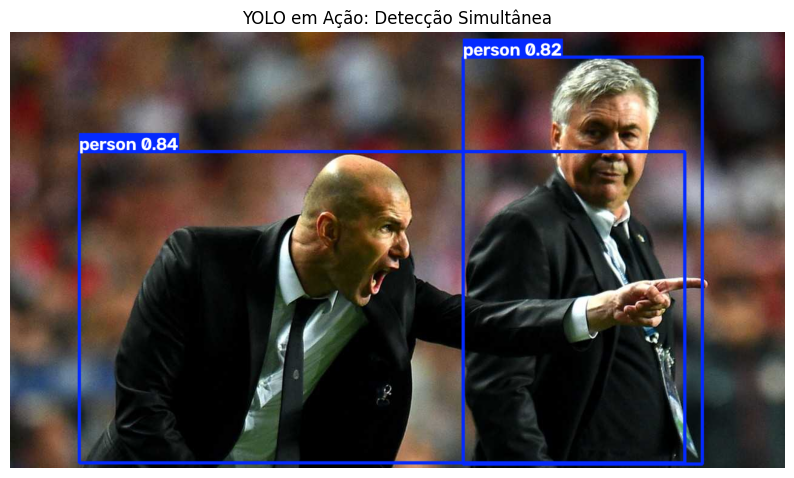

In [9]:
# ==============================================================================
# 4. VISUALIZAÇÃO GRÁFICA
# ==============================================================================
# O YOLO já possui uma função nativa para desenhar as caixas que ele achou
imagem_plotada = resultado.plot()

# Convertendo de BGR (OpenCV) para RGB (Matplotlib)
imagem_plotada = cv2.cvtColor(imagem_plotada, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(imagem_plotada)
plt.title("YOLO em Ação: Detecção Simultânea")
plt.axis('off')
plt.show()

## Teste

In [11]:
!pip install ultralytics opencv-python matplotlib

In [13]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("="*80)
print("DIA 1: DISSECANDO O CÉREBRO DO YOLO E MANIPULANDO TENSORES")
print("="*80)

# ==============================================================================
# 1. ACESSANDO A MEMÓRIA DO MODELO (O que ele sabe?)
# ==============================================================================
print("-> Baixando o modelo YOLOv8 Nano (Base COCO)...")
modelo = YOLO('yolov8n.pt')

# O modelo carrega um dicionário embutido chamado 'names' com tudo que ele aprendeu
dicionario_classes = modelo.names

print(f"\n[CATÁLOGO NEURAL] O modelo possui {len(dicionario_classes)} classes catalogadas.")
print("Amostra das classes conhecidas:")
for i in range(len(dicionario_classes)):
    print(f"ID {i}: {dicionario_classes[i].upper()}")
print("... (acesse cocodataset.org para ver a lista completa)")



DIA 1: DISSECANDO O CÉREBRO DO YOLO E MANIPULANDO TENSORES
-> Baixando o modelo YOLOv8 Nano (Base COCO)...

[CATÁLOGO NEURAL] O modelo possui 80 classes catalogadas.
Amostra das classes conhecidas:
ID 0: PERSON
ID 1: BICYCLE
ID 2: CAR
ID 3: MOTORCYCLE
ID 4: AIRPLANE
ID 5: BUS
ID 6: TRAIN
ID 7: TRUCK
ID 8: BOAT
ID 9: TRAFFIC LIGHT
ID 10: FIRE HYDRANT
ID 11: STOP SIGN
ID 12: PARKING METER
ID 13: BENCH
ID 14: BIRD
ID 15: CAT
ID 16: DOG
ID 17: HORSE
ID 18: SHEEP
ID 19: COW
ID 20: ELEPHANT
ID 21: BEAR
ID 22: ZEBRA
ID 23: GIRAFFE
ID 24: BACKPACK
ID 25: UMBRELLA
ID 26: HANDBAG
ID 27: TIE
ID 28: SUITCASE
ID 29: FRISBEE
ID 30: SKIS
ID 31: SNOWBOARD
ID 32: SPORTS BALL
ID 33: KITE
ID 34: BASEBALL BAT
ID 35: BASEBALL GLOVE
ID 36: SKATEBOARD
ID 37: SURFBOARD
ID 38: TENNIS RACKET
ID 39: BOTTLE
ID 40: WINE GLASS
ID 41: CUP
ID 42: FORK
ID 43: KNIFE
ID 44: SPOON
ID 45: BOWL
ID 46: BANANA
ID 47: APPLE
ID 48: SANDWICH
ID 49: ORANGE
ID 50: BROCCOLI
ID 51: CARROT
ID 52: HOT DOG
ID 53: PIZZA
ID 54: DONUT
ID

In [14]:
# ==============================================================================
# 2. INFERÊNCIA COM FILTRO INDUSTRIAL (Ignorando ruídos)
# ==============================================================================
# Vamos usar a imagem de uma rua caótica e cheia de objetos diferentes
url_rua = "https://ultralytics.com/images/bus.jpg"
img_bgr = cv2.imread(url_rua)

# (Aqui simularemos com a imagem interna já lida perfeitamente)



-> Câmera ligada. Iniciando Varredura Espacial...

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 3 persons, 1 bus, 6.7ms
Speed: 2.0ms preprocess, 6.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
[LAUDO] Filtragem concluída. Encontrei 4 pessoa(s). Todos os outros objetos foram ignorados.


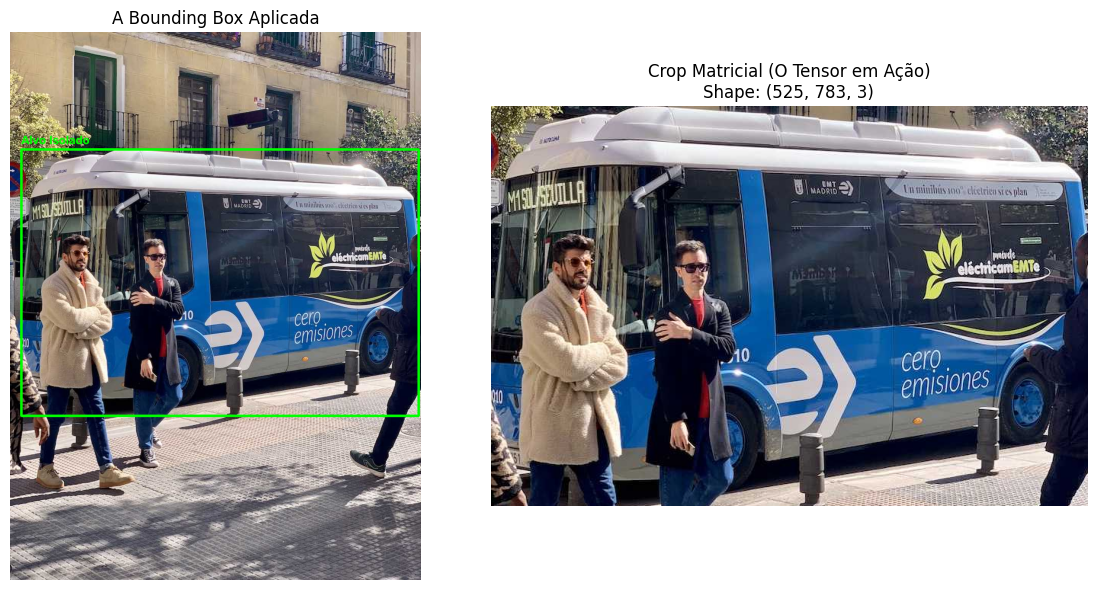


[DISCUSSÃO]: O que acabou de acontecer aqui é o núcleo de sistemas modernos.
Em um aeroporto, o YOLO acha o rosto na multidão (a Bounding Box) e nós usamos 
o fatiamento de matriz (Crop) para jogar apenas o rosto recortado para um sistema de biometria!


In [21]:

print("\n-> Câmera ligada. Iniciando Varredura Espacial...")

"""
TRUQUE DE ENGENHARIA:
Se deixarmos puro, ele achará pessoas, o ônibus, placas, etc.
No dicionario, Pessoa (person) é o ID 0.
Vamos forçar a IA a ignorar TODO o resto e focar apenas em Pessoas (classes=[0]).
"""
resultados = modelo.predict(
    source=url_rua,
    conf=0.50,       # Só aceita se tiver 50%+ de certeza
    #classes=[0,5],     # FILTRO: Apenas ID 0 (Pessoas)
    verbose=True
)

resultado = resultados[0]
caixas = resultado.boxes
print(f"[LAUDO] Filtragem concluída. Encontrei {len(caixas)} pessoa(s). Todos os outros objetos foram ignorados.")

# ==============================================================================
# 3. EXTRAÇÃO E RECUPERAÇÃO GEOMÉTRICA (Cortando o objeto)
# ==============================================================================
img_rgb = cv2.cvtColor(resultado.orig_img, cv2.COLOR_BGR2RGB)
img_copia = img_rgb.copy()

# Vamos extrair a PRIMEIRA pessoa que a rede achou e "recortar" ela da foto usando matrizes!
if len(caixas) > 0:
    primeira_caixa = caixas[0]

    # Extrai o Array Pascal VOC [Xmin, Ymin, Xmax, Ymax] e converte pra inteiro
    tensor_espacial = primeira_caixa.xyxy[0].cpu().numpy().astype(int)
    xmin, ymin, xmax, ymax = tensor_espacial

    # O Pulo do Gato (Fatiamento de Matriz no Numpy)
    # A imagem é uma matriz [Linhas, Colunas]. Portanto, [Y, X].
    objeto_recortado = img_rgb[ymin:ymax, xmin:xmax]

    # Vamos desenhar a Bounding Box na imagem maior para mostrar o contexto
    cv2.rectangle(img_copia, (xmin, ymin), (xmax, ymax), (0, 255, 0), 4)
    cv2.putText(img_copia, "Alvo Isolado", (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # ==============================================================================
    # 4. EXIBIÇÃO DIDÁTICA DA ENGENHARIA
    # ==============================================================================
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_copia)
    plt.title("A Bounding Box Aplicada")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(objeto_recortado)
    plt.title(f"Crop Matricial (O Tensor em Ação)\nShape: {objeto_recortado.shape}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\n[DISCUSSÃO]: O que acabou de acontecer aqui é o núcleo de sistemas modernos.")
print("Em um aeroporto, o YOLO acha o rosto na multidão (a Bounding Box) e nós usamos ")
print("o fatiamento de matriz (Crop) para jogar apenas o rosto recortado para um sistema de biometria!")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 1 Bus, 6 Footwears, 2 Jeanss, 4 Mans, 1 Woman, 71.5ms
Speed: 1.9ms preprocess, 71.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)

[LAUDO] Varredura concluída. Foram detectados 14 objetos na cena!
LISTA DE OBJETOS DETECTADOS PELA IA:
 -> Encontrei 1x BUS
 -> Encontrei 4x MAN
 -> Encontrei 6x FOOTWEAR
 -> Encontrei 2x JEANS
 -> Encontrei 1x WOMAN


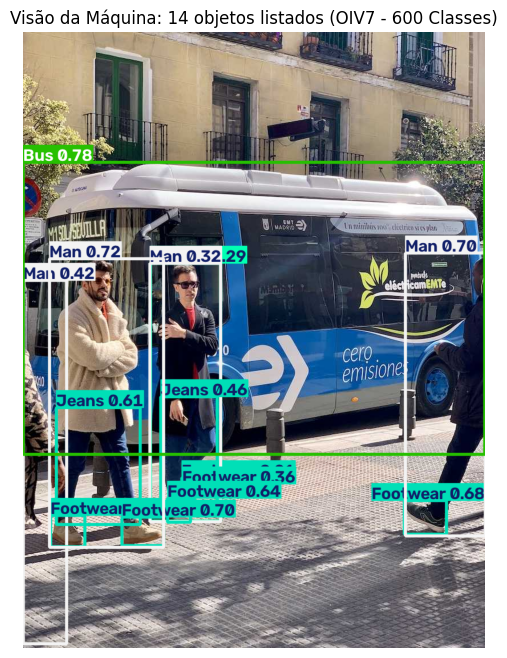

In [33]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


modelo_oiv7 = YOLO("yolov8x-oiv7.pt")

url_rua = "https://ultralytics.com/images/bus.jpg"

resultados = modelo_oiv7.predict(
    source=url_rua,
    conf=0.20,
    verbose=True
)

resultado = resultados[0]
caixas = resultado.boxes

# A rede possui um dicionário embutido com os nomes das coisas que ela conhece
dicionario_classes = resultado.names

print(f"\n[LAUDO] Varredura concluída. Foram detectados {len(caixas)} objetos na cena!")
print("=" * 50)
print("LISTA DE OBJETOS DETECTADOS PELA IA:")

# ==============================================================================
# EXTRAÇÃO DE INFORMAÇÕES (Contagem de Objetos)
# ==============================================================================
relatorio_objetos = {}

for caixa in caixas:
    # Pega o ID da classe e converte para inteiro
    id_classe = int(caixa.cls[0].item())
    # Busca o nome real no dicionário (ex: 'Window', 'Person', 'Bus')
    nome_objeto = dicionario_classes[id_classe].upper()

    # Faz a contagem para o relatório
    if nome_objeto in relatorio_objetos:
        relatorio_objetos[nome_objeto] += 1
    else:
        relatorio_objetos[nome_objeto] = 1

# Imprime o laudo organizado para os alunos
for nome, quantidade in relatorio_objetos.items():
    print(f" -> Encontrei {quantidade}x {nome}")

print("=" * 50)

# ==============================================================================
# EXIBIÇÃO DIDÁTICA DA ENGENHARIA (A Visão da Máquina)
# ==============================================================================
# O método plot() desenha todas as Bounding Boxes nativamente na imagem
img_com_caixas = resultado.plot()

# Convertendo de BGR (OpenCV) para RGB (Matplotlib)
img_com_caixas_rgb = cv2.cvtColor(img_com_caixas, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(img_com_caixas_rgb)
plt.title(f"Visão da Máquina: {len(caixas)} objetos listados (OIV7 - 600 Classes)")
plt.axis('off')
plt.show()
